
# CART for Regression


In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Modeling
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Display
pd.set_option("display.max_columns", 200)
sns.set_theme(context="notebook", style="whitegrid")

## 1. Load the data and basic preprocessing

In [ ]:
# Read in the data (published by the United States Centers for Medicare and Medicaid Services)
# This is a 1% random sample of patients in the Medicare program, anonymized to protect the privacy of the patients
# Big data!
claims = pd.read_csv("claimsFull.csv")

# Note: The last column appears to be processed.
# Will remove this column because otherwise it dominates the CART model
if "monthsWithClaims" in claims.columns:
    claims = claims.drop(columns=["monthsWithClaims"])

# Keep a copy of raw 2010 reim\bursement before log transform for the first histogram
claims = claims.copy()
claims["reimb2010_raw"] = claims["reimb2010"]

In [ ]:
display(claims)

,reimb2010,reimb2008,reimb2009,age2010,male,race,heart.failure,kidney,cancer,copd,depression,diabetes,ihd,osteoporosis,arthritis,stroke,InpatientClaims,OutpatientClaims,OfficeVisit,EyeExam,EKG,xray,CTScan,PhysicalTherapy,Ambulance,acuity,costTrend,reimb2010_raw
0,390,320,360,97,0,White,0,0,0,0,0,1,1,0,0,0,0,0,4,1,0,1,0,0,0,0.235294,-0.018856,390
1,970,58800,2740,79,0,White,1,1,0,1,0,1,1,0,0,1,1,10,12,0,2,8,1,0,1,0.853591,-0.027265,970
2,5630,510,1580,87,0,White,1,0,0,0,0,1,1,0,0,0,0,2,10,0,1,2,1,1,0,0.175115,0.496742,5630
3,3480,2930,49330,79,0,White,1,1,0,1,1,1,1,1,1,0,3,7,14,1,1,6,4,3,3,0.709147,0.214955,3480
4,920,1500,1650,85,1,White,1,0,1,0,0,1,0,0,1,0,0,0,16,2,1,3,0,1,0,0.174603,0.231568,920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299670,8780,8110,30120,67,1,Block,1,1,0,1,1,1,1,0,1,0,3,26,21,4,2,6,1,2,3,0.292373,0.414620,8780
299671,2040,3100,4550,73,0,White,1,1,1,1,1,1,1,1,0,1,0,10,18,0,3,6,4,8,4,0.172549,0.005044,2040
299672,1430,1150,2340,69,0,White,1,0,0,0,0,1,1,1,1,0,0,3,4,0,1,0,0,0,2,0.372493,0.220884,1430
299673,1420,600,460,85,1,White,0,0,0,0,0,1,1,0,0,0,0,15,2,0,0,3,1,0,0,0.160377,-0.155840,1420


### Histogram of 2010 reimbursements (raw)

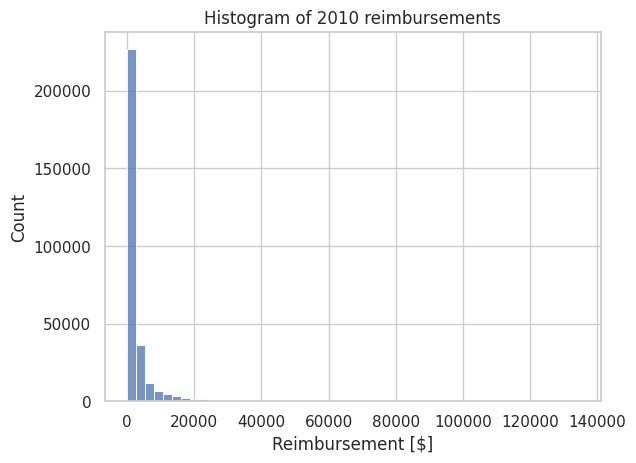

In [ ]:
# Visualize reimbursement data
ax = sns.histplot(data=claims, x="reimb2010_raw", bins=50)
ax.set_title("Histogram of 2010 reimbursements")
ax.set_xlabel("Reimbursement [$]")
ax.set_ylabel("Count")
plt.show()

### Log transform reimbursement columns

In [ ]:
# Log(1 + x) transform
for col in ["reimb2008", "reimb2009", "reimb2010"]:
    claims[col] = np.log10(claims[col] + 1)

# Rename columns to match the R script
claims = claims.rename(columns={
    "reimb2008": "log10_reimb2008",
    "reimb2009": "log10_reimb2009",
    "reimb2010": "log10_reimb2010"
})

### Histogram of 2010 reimbursements (log)

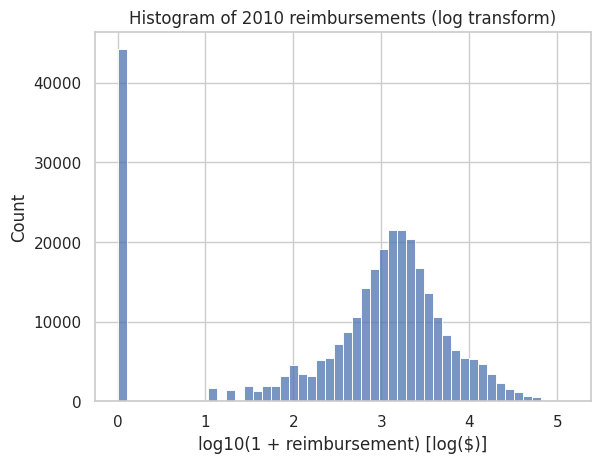

,log10_reimb2010,log10_reimb2008,log10_reimb2009,age2010,male,race,heart.failure,kidney,cancer,copd,depression,diabetes,ihd,osteoporosis,arthritis,stroke,InpatientClaims,OutpatientClaims,OfficeVisit,EyeExam,EKG,xray,CTScan,PhysicalTherapy,Ambulance,acuity,costTrend,reimb2010_raw
0,2.592177,2.506505,2.557507,97,0,White,0,0,0,0,0,1,1,0,0,0,0,0,4,1,0,1,0,0,0,0.235294,-0.018856,390
1,2.987219,4.769385,3.437909,79,0,White,1,1,0,1,0,1,1,0,0,1,1,10,12,0,2,8,1,0,1,0.853591,-0.027265,970
2,3.750586,2.708421,3.198932,87,0,White,1,0,0,0,0,1,1,0,0,0,0,2,10,0,1,2,1,1,0,0.175115,0.496742,5630
3,3.541704,3.467016,4.693120,79,0,White,1,1,0,1,1,1,1,1,1,0,3,7,14,1,1,6,4,3,3,0.709147,0.214955,3480
4,2.964260,3.176381,3.217747,85,1,White,1,0,1,0,0,1,0,0,1,0,0,0,16,2,1,3,0,1,0,0.174603,0.231568,920
5,3.049606,3.057286,3.385785,90,0,Hispanic,1,0,0,0,1,1,1,0,0,0,1,4,4,0,0,1,0,0,0,0.571429,0.078495,1120
6,3.061075,2.654177,4.175541,47,1,White,1,1,0,1,1,1,1,1,1,1,1,7,16,0,1,7,2,9,1,0.598833,0.129858,1150
7,0.000000,0.000000,1.908485,73,0,White,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.875000,0.240024,0
8,3.013259,2.399674,3.637590,86,0,White,1,0,0,0,1,1,1,1,0,0,0,5,6,1,1,1,1,0,2,0.479303,0.464121,1030
9,0.000000,0.000000,0.000000,85,0,Block,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.041667,0.000000,0


In [ ]:
ax = sns.histplot(data=claims, x="log10_reimb2010", bins=50)
ax.set_title("Histogram of 2010 reimbursements (log transform)")
ax.set_xlabel("log10(1 + reimbursement) [log($)]")
ax.set_ylabel("Count")
plt.show()

# Quick peek
display(claims.head(12))

## 2. Train/Test split and baseline

In [ ]:
# 70/30 split
train_df, test_df = train_test_split(
    claims, test_size=0.3, random_state=110, shuffle=True
)

baseline = train_df["log10_reimb2010"].mean()

display(train_df.sort_index().head(10))
display(train_df.sort_index().tail(5))
display(test_df.sort_index().head(10))
display(test_df.sort_index().tail(5))

,log10_reimb2010,log10_reimb2008,log10_reimb2009,age2010,male,race,heart.failure,kidney,cancer,copd,depression,diabetes,ihd,osteoporosis,arthritis,stroke,InpatientClaims,OutpatientClaims,OfficeVisit,EyeExam,EKG,xray,CTScan,PhysicalTherapy,Ambulance,acuity,costTrend,reimb2010_raw
0,2.592177,2.506505,2.557507,97,0,White,0,0,0,0,0,1,1,0,0,0,0,0,4,1,0,1,0,0,0,0.235294,-0.018856,390
1,2.987219,4.769385,3.437909,79,0,White,1,1,0,1,0,1,1,0,0,1,1,10,12,0,2,8,1,0,1,0.853591,-0.027265,970
2,3.750586,2.708421,3.198932,87,0,White,1,0,0,0,0,1,1,0,0,0,0,2,10,0,1,2,1,1,0,0.175115,0.496742,5630
3,3.541704,3.467016,4.693120,79,0,White,1,1,0,1,1,1,1,1,1,0,3,7,14,1,1,6,4,3,3,0.709147,0.214955,3480
4,2.964260,3.176381,3.217747,85,1,White,1,0,1,0,0,1,0,0,1,0,0,0,16,2,1,3,0,1,0,0.174603,0.231568,920
5,3.049606,3.057286,3.385785,90,0,Hispanic,1,0,0,0,1,1,1,0,0,0,1,4,4,0,0,1,0,0,0,0.571429,0.078495,1120
6,3.061075,2.654177,4.175541,47,1,White,1,1,0,1,1,1,1,1,1,1,1,7,16,0,1,7,2,9,1,0.598833,0.129858,1150
7,0.000000,0.000000,1.908485,73,0,White,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.875000,0.240024,0
9,0.000000,0.000000,0.000000,85,0,Block,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.041667,0.000000,0
11,0.000000,0.000000,0.000000,49,1,White,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.041667,0.000000,0


,log10_reimb2010,log10_reimb2008,log10_reimb2009,age2010,male,race,heart.failure,kidney,cancer,copd,depression,diabetes,ihd,osteoporosis,arthritis,stroke,InpatientClaims,OutpatientClaims,OfficeVisit,EyeExam,EKG,xray,CTScan,PhysicalTherapy,Ambulance,acuity,costTrend,reimb2010_raw
299666,0.000000,0.000000,0.000000,32,1,Block,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.041667,0.000000,0
299668,3.682235,3.143327,3.225568,63,1,Hispanic,0,0,0,0,0,1,1,0,0,0,0,7,14,0,1,1,0,0,1,0.156352,0.021176,4810
299669,0.000000,0.000000,0.000000,75,1,White,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.041667,0.000000,0
299672,3.155640,3.061075,3.369401,69,0,White,1,0,0,0,0,1,1,1,1,0,0,3,4,0,1,0,0,0,2,0.372493,0.220884,1430
299673,3.152594,2.778874,2.663701,85,1,White,0,0,0,0,0,1,1,0,0,0,0,15,2,0,0,3,1,0,0,0.160377,-0.155840,1420


,log10_reimb2010,log10_reimb2008,log10_reimb2009,age2010,male,race,heart.failure,kidney,cancer,copd,depression,diabetes,ihd,osteoporosis,arthritis,stroke,InpatientClaims,OutpatientClaims,OfficeVisit,EyeExam,EKG,xray,CTScan,PhysicalTherapy,Ambulance,acuity,costTrend,reimb2010_raw
8,3.013259,2.399674,3.637590,86,0,White,1,0,0,0,1,1,1,1,0,0,0,5,6,1,1,1,1,0,2,0.479303,0.464121,1030
10,0.000000,0.000000,0.000000,37,1,White,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.041667,0.000000,0
12,3.893817,2.987219,3.029789,79,1,White,0,0,0,1,1,0,1,0,1,0,0,1,10,1,0,2,0,1,0,0.171569,0.174770,7830
17,3.487280,3.415140,3.041787,72,1,White,0,1,0,0,0,0,1,0,1,0,0,0,9,3,2,4,0,1,0,0.281081,-0.283051,3070
18,2.935003,2.716838,2.935003,80,1,White,0,0,0,0,0,1,0,1,0,0,0,4,6,0,0,0,2,4,0,0.217391,0.190176,860
27,0.000000,0.000000,0.000000,47,1,White,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.041667,0.000000,0
28,3.779669,4.607359,4.769901,99,1,White,1,1,1,0,1,1,1,1,0,0,3,27,21,3,9,7,0,4,58,0.242151,0.127522,6020
34,3.344589,3.872215,4.445620,72,1,White,1,1,0,1,1,1,1,1,0,1,3,3,10,0,2,1,0,1,2,0.511740,0.067231,2210
35,3.029789,3.448861,3.596707,86,0,Other,1,0,1,0,1,1,1,1,1,0,0,7,30,4,2,15,3,11,3,0.118343,0.222131,1070
36,0.000000,0.000000,0.000000,50,1,White,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.041667,0.000000,0


,log10_reimb2010,log10_reimb2008,log10_reimb2009,age2010,male,race,heart.failure,kidney,cancer,copd,depression,diabetes,ihd,osteoporosis,arthritis,stroke,InpatientClaims,OutpatientClaims,OfficeVisit,EyeExam,EKG,xray,CTScan,PhysicalTherapy,Ambulance,acuity,costTrend,reimb2010_raw
299661,3.475816,3.079543,3.320354,93,1,White,0,0,0,0,0,1,0,0,0,0,0,8,14,3,0,0,2,8,0,0.127660,0.335185,2990
299667,3.164650,4.438874,4.272793,80,0,White,1,1,0,0,1,1,1,1,0,1,4,6,13,1,4,5,9,0,11,0.432807,-0.180665,1460
299670,3.943544,3.909074,4.478869,67,1,Block,1,1,0,1,1,1,1,0,1,0,3,26,21,4,2,6,1,2,3,0.292373,0.414620,8780
299671,3.309843,3.491502,3.658107,73,0,White,1,1,1,1,1,1,1,1,0,1,0,10,18,0,3,6,4,8,4,0.172549,0.005044,2040
299674,3.926908,3.928447,4.833345,70,0,White,1,1,0,1,1,1,1,0,1,0,2,12,24,5,2,7,0,14,1,0.772484,0.280000,8450



## 3. Tiny 0.1% subset & 2-feature Decision Tree

We sample ~0.1% of the training data and fit a small CART on:
- Features: `log10_reimb2009`, `OfficeVisit`
- Target: `log10_reimb2010`


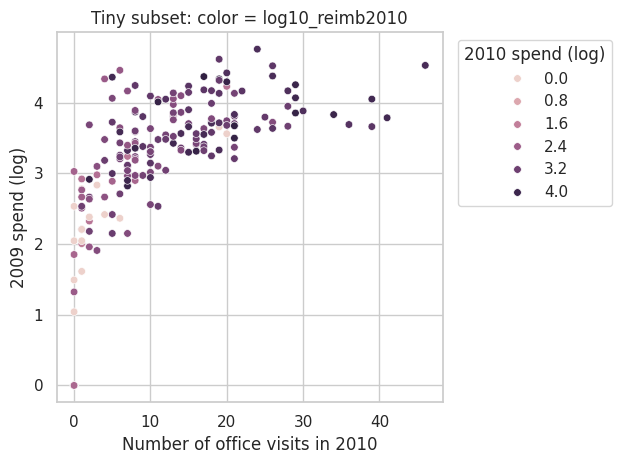

In [ ]:
# 0.1% sample (round at least 1 row)
rng = np.random.default_rng(144)
n_vis = max(1, int(0.001 * len(train_df)))
vis_idx = rng.choice(len(train_df), size=n_vis, replace=False)
viz_df = train_df.iloc[vis_idx][["log10_reimb2010", "log10_reimb2009", "OfficeVisit"]].dropna()

# Fit a small decision tree
tree_direct = tree.DecisionTreeRegressor(
    min_samples_leaf=5,
    ccp_alpha=0.0,              # keep splits; we'll control complexity via min_samples_leaf here
    random_state=144
)
tree_direct.fit(viz_df[["log10_reimb2009", "OfficeVisit"]], viz_df["log10_reimb2010"])

# Scatter colored by target; this mirrors the "boxes" intuition w/o drawing exact split boxes
ax = sns.scatterplot(
    data=viz_df,
    x="OfficeVisit",
    y="log10_reimb2009",
    hue="log10_reimb2010",
    s=30
)

ax.set_title("Tiny subset: color = log10_reimb2010")
ax.set_xlabel("Number of office visits in 2010")
ax.set_ylabel("2009 spend (log)")
plt.legend(title="2010 spend (log)", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


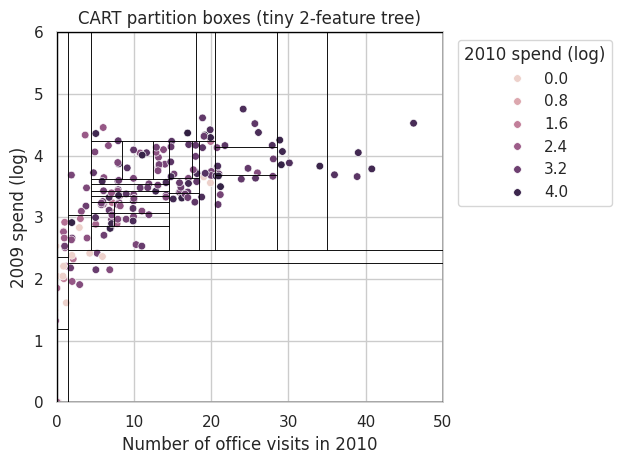

tiny tree depth: 12 nodes: 61


In [ ]:
from matplotlib.patches import Rectangle
from sklearn.tree import _tree

# X_small = viz_df[["log10_reimb2009", "OfficeVisit"]]
feat_names_2 = ["log10_reimb2009", "OfficeVisit"]  # index 0 = y-axis feature, 1 = x-axis feature

# Outer bounds similar to the R code
x_min = 0 # np.floor(viz_df["OfficeVisit"].min() / 5) * 5 - 0.2
x_max = 50 # np.ceil(viz_df["OfficeVisit"].max() / 5) * 5
y_min = 0 # np.floor(viz_df["log10_reimb2009"].min() / 5) * 5 - 0.2
y_max = 6 # np.ceil(viz_df["log10_reimb2009"].max() / 5) * 5

def draw_leaf_boxes(ax, tree, x0, x1, y0, y1):
    """Draw an axis-aligned rectangle for every leaf region in the 2D tree."""
    t = tree.tree_
    UNDEF = _tree.TREE_UNDEFINED

    def recurse(node, xl, xr, yb, yt):
        f = t.feature[node]
        thr = t.threshold[node]

        # Leaf → draw the current region
        if f == UNDEF:
            if xr > xl and yt > yb:  # only draw if region has area
                ax.add_patch(Rectangle((xl, yb), xr - xl, yt - yb,
                                       fill=False, linewidth=0.5, edgecolor="black", zorder=3))
            return

        fname = feat_names_2[f]

        if fname == "OfficeVisit":  # vertical split at x = thr
            # If split is completely to the left of the region, we are entirely on the RIGHT child
            if thr <= xl:
                recurse(t.children_right[node], xl, xr, yb, yt)
            # If split is completely to the right of the region, we are entirely on the LEFT child
            elif thr >= xr:
                recurse(t.children_left[node], xl, xr, yb, yt)
            else:
                # Proper split inside current [xl, xr]
                recurse(t.children_left[node],  xl, thr, yb, yt)  # x <= thr
                recurse(t.children_right[node], thr, xr, yb, yt)  # x > thr

        elif fname == "log10_reimb2009":  # horizontal split at y = thr
            if thr <= yb:
                recurse(t.children_right[node], xl, xr, yb, yt)
            elif thr >= yt:
                recurse(t.children_left[node], xl, xr, yb, yt)
            else:
                recurse(t.children_left[node],  xl, xr, yb, thr)  # y <= thr
                recurse(t.children_right[node], xl, xr, thr, yt)  # y > thr

    recurse(0, x0, x1, y0, y1)

# --- Plot scatter + boxes ---
fig, ax = plt.subplots()

# jitter OfficeVisit slightly (like R's jitter)
x_jitter = viz_df["OfficeVisit"] + np.random.default_rng(0).normal(0, 0.15, size=len(viz_df))
sns.scatterplot(x=x_jitter,
                y=viz_df["log10_reimb2009"],
                hue=viz_df["log10_reimb2010"],
                s=30, ax=ax, zorder=2)

ax.set_title("CART partition boxes (tiny 2-feature tree)")
ax.set_xlabel("Number of office visits in 2010")
ax.set_ylabel("2009 spend (log)")

# Draw partition rectangles
draw_leaf_boxes(ax, tree_direct, x_min, x_max, y_min, y_max)

# Draw outer frame
ax.add_patch(Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                       fill=False, linewidth=1, edgecolor="black", zorder=3))

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.legend(title="2010 spend (log)", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# (Optional) quick sanity check:
print("tiny tree depth:", tree_direct.get_depth(), "nodes:", tree_direct.tree_.node_count)


## 4. CART on reimbursement data

In [ ]:
# For visualizing trees

import graphviz
import math
from IPython.display import display

def plot_tree_graphviz(model, feat_names, max_depth=3, title=None, export=False):
    """
    Generates and displays a customized decision tree plot.

    Args:
        model (DecisionTreeRegressor): The trained scikit-learn tree model.
        feat_names (list): A list of feature names.
        max_depth (int): The maximum depth of the tree to display.
        title (str, optional): An optional title for the graph.
        export (bool): If True, exports the plot as a PNG image to the current directory.
    """
    dot = graphviz.Digraph(
        'tree',
        node_attr={'shape': 'box', 'style': 'rounded,filled', 'fontname': 'helvetica'},
        edge_attr={'fontname': 'helvetica', 'fontsize': '12'}
    )
    dot.attr('graph', rankdir='TB', label=title or '', fontname='helvetica', fontsize='16')

    tree_ = model.tree_

    def build_graph_recursive(node_id=0, depth=0):
        is_leaf = tree_.children_left[node_id] == tree_.children_right[node_id]

        if is_leaf:
            leaf_value = f"{tree_.value[node_id][0][0]:.3f}"
            dot.node(str(node_id), label=leaf_value, shape='oval', fillcolor='lightgoldenrodyellow')
        else:
            feature_index = tree_.feature[node_id]
            threshold = tree_.threshold[node_id]
            split_condition = f"{feat_names[feature_index]} < {threshold:.3f}"
            dot.node(str(node_id), label=split_condition, fillcolor='white')

            if depth < max_depth - 1:
                left_child_id = tree_.children_left[node_id]
                right_child_id = tree_.children_right[node_id]

                dot.edge(str(node_id), str(left_child_id), label='yes')
                dot.edge(str(node_id), str(right_child_id), label='no')

                build_graph_recursive(left_child_id, depth + 1)
                build_graph_recursive(right_child_id, depth + 1)
            else:
                left_ellipsis_id = f"ellipsis_left_{node_id}"
                right_ellipsis_id = f"ellipsis_right_{node_id}"

                dot.node(left_ellipsis_id, label="...", shape='plaintext')
                dot.edge(str(node_id), left_ellipsis_id, label='yes')

                dot.node(right_ellipsis_id, label="...", shape='plaintext')
                dot.edge(str(node_id), right_ellipsis_id, label='no')

    build_graph_recursive()

    # --- Added Export Logic ---
    if export:
        # Saves the graph to 'tree.png' and removes the intermediate source file
        dot.render('tree', format='png', cleanup=True)
        print("Tree exported to 'tree.png'")

    display(dot)

In [ ]:
# Separate features/target
target_cols = ["log10_reimb2010", "reimb2010_raw"]
X_train = train_df.drop(columns=target_cols)
y_train = train_df["log10_reimb2010"].copy()
X_test  = test_df.drop(columns=target_cols)
y_test  = test_df["log10_reimb2010"].copy()

# One-hot encode categorical columns (similar to R using all '.' features implicitly)
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)

# Align columns
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Feature names
feat_names = list(X_train_enc.columns)

# Base tree (analogous to rpart(,..., minbucket=25, cp=0.002))
tree_base = tree.DecisionTreeRegressor(
    min_samples_leaf=25,
    ccp_alpha=0.002,
    random_state=123
)
tree_base.fit(X_train_enc, y_train)

# Compare a few ccp_alpha; keep min_samples_leaf fixed for parity
alphas = [0.001, 0.002, 0.005]
depths = {}
for alpha in alphas:
    model = tree.DecisionTreeRegressor(min_samples_leaf=50, ccp_alpha=alpha, random_state=123)
    model.fit(X_train_enc, y_train)
    depths[alpha] = model.get_depth()

depths

{0.001: 5, 0.002: 4, 0.005: 3}

### Visualizing tree of depth 3

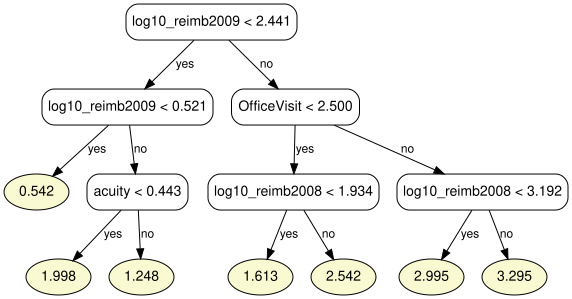

In [ ]:
tree_depth3 = tree.DecisionTreeRegressor(min_samples_leaf=25, ccp_alpha=0.005, random_state=123)
tree_depth3.fit(X_train_enc, y_train)
plot_tree_graphviz(tree_depth3, feat_names, max_depth=math.inf, title="")

### Visualizing tree of depth 3 using scikit-learn

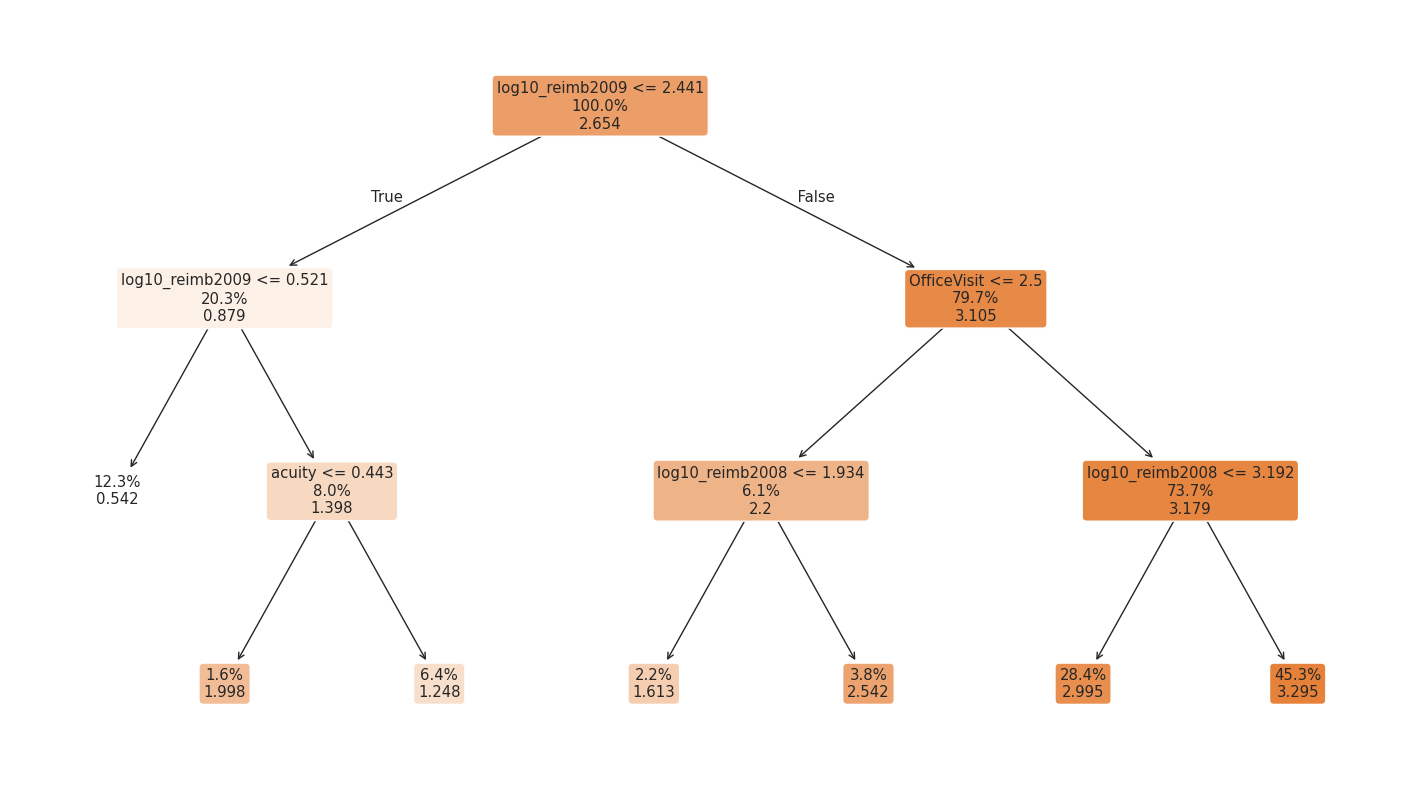

In [ ]:
# In sklearn ... + tree sklearn plot_tree.

plt.figure(figsize=(18, 10))
tree.plot_tree(
    tree_depth3,
    feature_names = feat_names,
    filled=True,
    rounded=True,
    impurity=False,
    label="none",
    proportion=True
)
plt.show()

### Three specific trees to compare (small vs larger ccp_alpha)

In [ ]:
# "tree1" ~ very small alpha to allow more splits
tree1 = tree.DecisionTreeRegressor(min_samples_leaf=25, ccp_alpha=1e-5, random_state=123)
tree1.fit(X_train_enc, y_train)

# "tree2" ~ moderate alpha
tree2 = tree.DecisionTreeRegressor(min_samples_leaf=25, ccp_alpha=0.001, random_state=123)
tree2.fit(X_train_enc, y_train)

# "tree3" ~ large alpha
tree3 = tree.DecisionTreeRegressor(min_samples_leaf=25, ccp_alpha=0.005, random_state=123)
tree3.fit(X_train_enc, y_train)

DecisionTreeRegressor(ccp_alpha=0.005, min_samples_leaf=25, random_state=123)

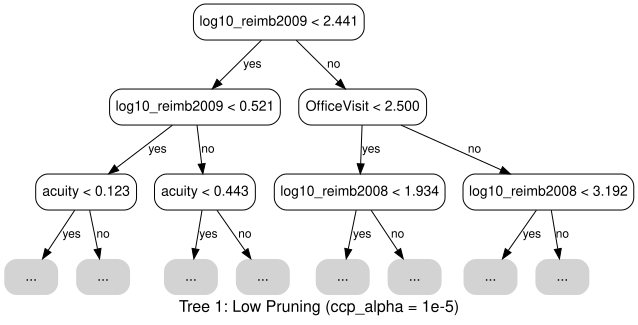

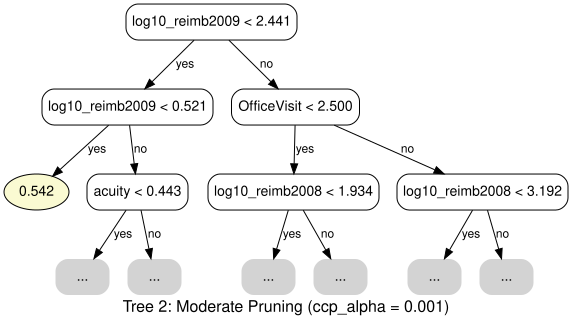

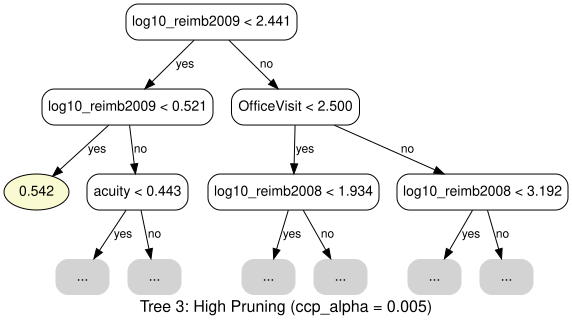

In [ ]:
plot_tree_graphviz(tree1, feat_names, max_depth=3, title="Tree 1: Low Pruning (ccp_alpha = 1e-5)")
plot_tree_graphviz(tree2, feat_names, max_depth=3, title="Tree 2: Moderate Pruning (ccp_alpha = 0.001)")
plot_tree_graphviz(tree3, feat_names, max_depth=3, title="Tree 3: High Pruning (ccp_alpha = 0.005)")
# plot_tree_graphviz(tree1, feat_names, max_depth=math.inf, title="Tree 1: Low Pruning (ccp_alpha = 1e-5)", export=True)
# plot_tree_graphviz(tree2, feat_names, max_depth=math.inf, title="Tree 2: Moderate Pruning (ccp_alpha = 0.001)", export=True)
# plot_tree_graphviz(tree3, feat_names, max_depth=math.inf, title="Tree 3: High Pruning (ccp_alpha = 0.005)", export=True)

### Predictions & display sample

In [ ]:
# We'll use tree_base as the 'final' model
tree_final = tree_base

pred_train_final = tree_final.predict(X_train_enc)
pred_test_final  = tree_final.predict(X_test_enc)

# Show a few columns + prediction (first 11 columns if available)
display_cols = list(test_df.columns[:11])
df_display = test_df[display_cols].copy()
df_display["PredictTest"] = pred_test_final

# Mimic headTail: show head(18) and tail(5)
display(df_display.head(18))
display(df_display.tail(5))

,log10_reimb2010,log10_reimb2008,log10_reimb2009,age2010,male,race,heart.failure,kidney,cancer,copd,depression,PredictTest
268106,0.000000,0.000000,2.232996,95,0,Block,0,0,0,0,0,1.247573
146649,3.748266,2.944976,3.447313,67,1,White,0,1,0,0,0,3.072889
156992,0.000000,0.000000,0.000000,67,0,White,0,0,0,0,0,0.541700
71797,3.230704,3.190612,2.733197,81,1,White,1,1,0,0,1,3.072889
238955,2.991669,3.699057,2.954725,67,1,White,0,0,1,0,1,2.278924
32412,2.532754,2.959518,2.949878,71,0,White,0,0,0,0,0,2.866664
271773,3.316180,3.481586,3.415140,49,1,White,1,0,0,0,1,3.351977
63257,3.212454,3.296884,3.117603,80,1,White,0,0,0,0,1,3.118698
259320,0.000000,0.000000,0.000000,78,1,White,0,0,0,0,0,0.541700
18282,3.033826,2.892651,3.288026,76,1,White,1,0,0,0,0,3.072889


,log10_reimb2010,log10_reimb2008,log10_reimb2009,age2010,male,race,heart.failure,kidney,cancer,copd,depression,PredictTest
127188,3.004751,3.004751,3.740442,79,0,White,0,0,0,1,1,3.072889
94296,3.207096,2.756636,3.025715,82,1,White,0,0,0,0,0,3.072889
45039,0.000000,0.000000,0.000000,70,0,Hispanic,0,0,0,0,0,0.541700
64777,0.000000,0.000000,0.000000,83,0,White,0,0,0,0,0,0.541700
265575,3.474362,3.749814,3.267406,28,0,White,1,0,0,0,0,3.118698


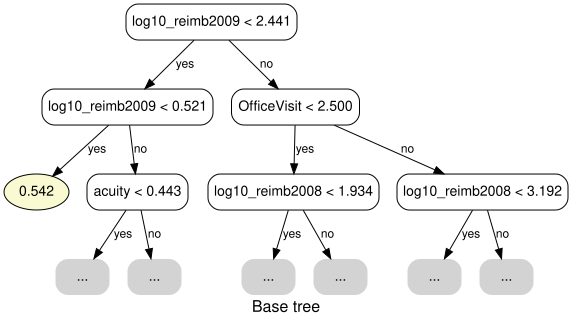

In [ ]:
plot_tree_graphviz(tree_final, feat_names, max_depth=3, title="Base tree")
# plot_tree_graphviz(tree_final, feat_names, max_depth=math.inf, title="Base tree", export=True)

### R-Squared and OSR-Squared for CART

In [ ]:
# Helper to compute OSR^2 relative to training-mean baseline, similar to R code
def osr2(y_true, y_pred, baseline_mean):
    sst = np.sum((y_true - baseline_mean) ** 2)
    sse = np.sum((y_pred - y_true) ** 2)
    return 1 - sse / sst

# Baseline
baseline = y_train.mean()

# Final tree
sst_train = np.sum((y_train - baseline) ** 2)
sse_train = np.sum((pred_train_final - y_train) ** 2)
R2_CART_treeFinal = 1 - sse_train / sst_train

sst_test = np.sum((y_test - baseline) ** 2)
sse_test = np.sum((pred_test_final - y_test) ** 2)
OSR2_CART_treeFinal = 1 - sse_test / sst_test

# Smaller alpha tree ("tree1") for comparison
pred_train_smaller = tree1.predict(X_train_enc)
pred_test_smaller  = tree1.predict(X_test_enc)

sst_train_s = np.sum((y_train - baseline) ** 2)
sse_train_s = np.sum((pred_train_smaller - y_train) ** 2)
R2_CART_treeSmaller = 1 - sse_train_s / sst_train_s

sst_test_s = np.sum((y_test - baseline) ** 2)
sse_test_s = np.sum((pred_test_smaller - y_test) ** 2)
OSR2_CART_treeSmaller = 1 - sse_test_s / sst_test_s

print(f"""Base tree R^2: {R2_CART_treeFinal:.3f}
Base tree OSR^2: {OSR2_CART_treeFinal:.3f}
Low pruning tree R^2: {R2_CART_treeSmaller:.3f}
Low pruning tree OSR^2: {OSR2_CART_treeSmaller:.3f}""")

Base tree R^2: 0.599
Base tree OSR^2: 0.601
Low pruning tree R^2: 0.655
Low pruning tree OSR^2: 0.593


## 6. Linear Regression & Smart Baseline

In [ ]:
import statsmodels.formula.api as smf # Changed from statsmodels.api as sm
import numpy as np
import pandas as pd

# --- Assume the following variables are pre-defined ---
# X_train_enc, y_train, X_test_enc, y_test (as pandas DataFrames/Series)
# baseline (e.g., y_train.mean())
# train_df, test_df (with the "log10_reimb2009" column)
# ---------------------------------------------------

## --- Linear Regression using statsmodels.formula ---

# Combine X_train_enc and y_train into a single DataFrame for the formula interface
train_data_for_formula = X_train_enc.copy()
train_data_for_formula['log10_reimb2010'] = y_train

# Construct the formula string, wrapping feature names in Q() for special characters
# Patsy (used by statsmodels.formula) requires special characters to be quoted with Q()
formula = 'log10_reimb2010 ~ ' + ' + '.join([f'Q(\'{col}\')' for col in X_train_enc.columns])
# The line below caused a SyntaxError because '.' is not a valid patsy feature name.
# formula = 'log10_reimb2010 ~ .'

# 1. Fit the Ordinary Least Squares (OLS) model
# smf.ols automatically adds an intercept and handles categorical variables.
sm_model = smf.ols(formula=formula, data=train_data_for_formula).fit()

# 2. Make predictions on the test set
# For formula API, predict directly on the test features. It will correctly use the fitted model's structure.
pred_lr_test = sm_model.predict(X_test_enc)

# 3. Calculate in-sample R^2
pred_lr_train = sm_model.predict(X_train_enc)
sst_train = np.sum((y_train - y_train.mean()) ** 2)
sse_train = np.sum((pred_lr_train - y_train) ** 2)
R2_Lr = 1 - sse_train / sst_train

# 4. Calculate out-of-sample OSR^2 (relative to training-mean baseline)
SST = np.sum((y_test - baseline) ** 2)
SSE = np.sum((pred_lr_test - y_test) ** 2)
OSR2_Lr = 1 - SSE / SST

## --- Smart Baseline Calculation (no changes needed) ---

# Train metrics
SST_train = np.sum((y_train - baseline) ** 2)
SSE_train = np.sum((train_df["log10_reimb2009"] - y_train) ** 2)
R2_smart_baseline = 1 - SSE_train / SST_train

# Test metrics
SST_test = np.sum((y_test - baseline) ** 2)
SSE_test = np.sum((test_df["log10_reimb2009"] - y_test) ** 2)
OSR2_smart_baseline = 1 - SSE_test / SST_test

## --- Print Performance Metrics ---

print("## Performance Metrics\n")
print(f"""Linear Regression R^2: {R2_Lr:.3f}
Linear Regression OSR^2: {OSR2_Lr:.3f}
Smart Baseline R^2: {R2_smart_baseline:.3f}
Smart Baseline OSR^2: {OSR2_smart_baseline:.3f}""")
print("\n" + "="*40 + "\n")


## --- Model Summary with Significance ---

def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

def print_summary_with_stars(model):
    summary_table = model.summary2().tables[1]
    # statsmodels sometimes uses "P>|z|" instead of "P>|t|"
    p_col = "P>|z|" if "P>|z%" in summary_table.columns else "P>|t|"
    summary_table['Signif'] = summary_table[p_col].apply(significance_stars)
    rounded_table = summary_table.round(4)
    table_string = rounded_table.to_string(header=True)
    lines = table_string.split('\n')
    print("## Linear Model Coefficients")
    print("=" * len(lines[0]))
    print(lines[0])
    print("-" * len(lines[0]))
    print('\n'.join(lines[1:]))
    print("=" * len(lines[0]))
    print("---")
    print("Significance codes: 0 '***' 0.001 '**' 0.05 '*' 0.1 ' ' 1")

# 5. Call the summary function with the statsmodels object
print_summary_with_stars(sm_model)

## Performance Metrics

Linear Regression R^2: 0.605
Linear Regression OSR^2: 0.608
Smart Baseline R^2: 0.411
Smart Baseline OSR^2: 0.416


## Linear Model Coefficients
                             Coef.  Std.Err.         t   P>|t|  [0.025  0.975] Signif
-------------------------------------------------------------------------------------
Intercept                   0.5198    0.0121   42.9165  0.0000  0.4961  0.5435    ***
Q('race_Hispanic')[T.True]  0.0021    0.0127    0.1669  0.8674 -0.0228  0.0271       
Q('race_Other')[T.True]    -0.0179    0.0103   -1.7438  0.0812 -0.0381  0.0022      .
Q('race_White')[T.True]     0.0139    0.0058    2.3858  0.0170  0.0025  0.0253      *
Q('log10_reimb2008')        0.3248    0.0032  102.5854  0.0000  0.3186  0.3310    ***
Q('log10_reimb2009')        0.4546    0.0036  126.6395  0.0000  0.4475  0.4616    ***
Q('age2010')                0.0007    0.0001    4.9068  0.0000  0.0004  0.0010    ***
Q('male')                  -0.0081    0.0035   -2.3226  0

## 7. Compare all models

In [ ]:
results = pd.DataFrame({
    "Smart Baseline": [R2_smart_baseline, OSR2_smart_baseline],
    "CART (small alpha)": [R2_CART_treeSmaller, OSR2_CART_treeSmaller],
    "CART (base alpha)": [R2_CART_treeFinal,  OSR2_CART_treeFinal],
    "Linear Regression": [R2_Lr, OSR2_Lr]
}, index=["R-Squared", "OSR-Squared"])

results

,Smart Baseline,CART (small alpha),CART (base alpha),Linear Regression
R-Squared,0.411467,0.655210,0.599406,0.604872
OSR-Squared,0.415628,0.593419,0.600832,0.608195
